In [79]:
# ============================================================
# STEP 2: LOAD THE DATA
# ============================================================
# We load the Excel files into pandas DataFrames.
# A DataFrame is like a table (rows and columns), similar to Excel.

# importing the necessary packages and creating the test and train data sets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("\n STEP 2: LOAD THE DATA")

training_set = pd.read_excel("Data_Train.xlsx")
test_set = pd.read_excel("Test_set.xlsx")

print(f"   Training data shape : {training_set.shape}  → {training_set.shape[0]} rows, {training_set.shape[1]} columns")
print(f"   Test data shape     : {test_set.shape}  → {test_set.shape[0]} rows, {test_set.shape[1]} columns")
print(f"\n   Columns in Training: {training_set.columns.tolist()}")
print(f"\n   First 3 rows of training data:")
print(training_set.head(3).to_string())
print("=" * 60)



 STEP 2: LOAD THE DATA
   Training data shape : (10683, 11)  → 10683 rows, 11 columns
   Test data shape     : (2671, 10)  → 2671 rows, 10 columns

   Columns in Training: ['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price']

   First 3 rows of training data:
       Airline Date_of_Journey    Source Destination                  Route Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR    05:50         13:15   7h 25m     2 stops         No info   7662
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK    09:25  04:25 10 Jun      19h     2 stops         No info  13882


In [80]:
print(f"   Training data shape : {training_set.shape}  → {training_set.shape[0]} rows, {training_set.shape[1]} columns")
print(f"   Test data shape     : {test_set.shape}  → {test_set.shape[0]} rows, {test_set.shape[1]} columns")
print(f"\n   Columns in Training: {training_set.columns.tolist()}")
print(f"\n   First 3 rows of training data:")
print(training_set.head(3).to_string())
print("=" * 60)

   Training data shape : (10683, 11)  → 10683 rows, 11 columns
   Test data shape     : (2671, 10)  → 2671 rows, 10 columns

   Columns in Training: ['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price']

   First 3 rows of training data:
       Airline Date_of_Journey    Source Destination                  Route Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR    05:50         13:15   7h 25m     2 stops         No info   7662
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK    09:25  04:25 10 Jun      19h     2 stops         No info  13882


In [81]:
# ============================================================
# STEP 3: EXPLORE THE DATA (EDA - Exploratory Data Analysis)
# ============================================================
# Before building a model, we understand what the data looks like.
 
print("\n🔍 STEP 3: Exploring the Data...")
 
print("\n   Missing values in Training Data:")
print(training_set.isnull().sum())
 
print(f"\n   Price Statistics (our TARGET - what we want to predict):")
print(training_set['Price'].describe())
 
print("\n   Unique Airlines:", training_set['Airline'].unique())
print("   Unique Sources:", training_set['Source'].unique())
print("   Unique Destinations:", training_set['Destination'].unique())
print("   Unique Total_Stops:", training_set['Total_Stops'].unique())
print("=" * 60)


🔍 STEP 3: Exploring the Data...

   Missing values in Training Data:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

   Price Statistics (our TARGET - what we want to predict):
count    10683.000000
mean      9087.064121
std       4611.359167
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64

   Unique Airlines: <StringArray>
[                           'IndiGo',                         'Air India',
                       'Jet Airways',                          'SpiceJet',
                 'Multiple carriers',                             'GoAir',
                           'Vistara',                          'Air Asia',
           'Vistara Premium economy',              'Jet Airways Business',
 'Multiple 

In [82]:
# ============================================================
# STEP 4: CLEAN THE DATA
# ============================================================
# Fix missing values, wrong formats, etc.
 
print("\n🧹 STEP 4: Cleaning Data...")
 
# Drop rows with missing values (only 1 row is missing in our data)
training_set.dropna(inplace=True)
test_set.dropna(inplace=True)
 
print(f"   After dropping nulls → Train: {training_set.shape[0]} rows, Test: {test_set.shape[0]} rows")
print("=" * 60)


🧹 STEP 4: Cleaning Data...
   After dropping nulls → Train: 10682 rows, Test: 2671 rows


In [83]:
# ============================================================
# STEP 5: FEATURE ENGINEERING
# ============================================================
# The raw data has dates and times as TEXT strings.
# We need to convert them into NUMBERS so ML models can use them.
# This is called "Feature Engineering" - creating useful new columns.
 
print("\n⚙️  STEP 5: Feature Engineering (Converting text → numbers)...")
 
def engineer_features(df):
    """
    This function takes raw flight data and extracts useful number features.
    We apply the same steps to both train and test data.
    """
    df = df.copy()  # Make a copy so we don't change the original
 
    # ── 5a. Date of Journey ──────────────────────────────────
    # "24/03/2019" → extract day=24, month=3
    df['Journey_Day']   = pd.to_datetime(df['Date_of_Journey'], dayfirst=True).dt.day
    df['Journey_Month'] = pd.to_datetime(df['Date_of_Journey'], dayfirst=True).dt.month
    df.drop('Date_of_Journey', axis=1, inplace=True)
    # WHY? ML models need numbers. "24/03/2019" means nothing to them.
    # But day=24 and month=3 (March) are numbers they can learn from.
 
    # ── 5b. Departure Time ───────────────────────────────────
    # "22:20" → hour=22, minute=20
    df['Dep_Hour']   = pd.to_datetime(df['Dep_Time']).dt.hour
    df['Dep_Minute'] = pd.to_datetime(df['Dep_Time']).dt.minute
    df.drop('Dep_Time', axis=1, inplace=True)
 
    # ── 5c. Arrival Time ─────────────────────────────────────
    # Arrival times sometimes have extra date info like "01:10 22 Mar"
    # We only want the time part "01:10"
    df['Arrival_Time'] = df['Arrival_Time'].str.strip().str.split(' ').str[0]
    df['Arrival_Hour']   = pd.to_datetime(df['Arrival_Time']).dt.hour
    df['Arrival_Minute'] = pd.to_datetime(df['Arrival_Time']).dt.minute
    df.drop('Arrival_Time', axis=1, inplace=True)
 
    # ── 5d. Duration ─────────────────────────────────────────
    # "2h 50m" → duration_hours=2, duration_minutes=50
    # Some entries are just "19h" (no minutes), handle that too
    def parse_duration(dur):
        dur = str(dur).strip()
        hours = 0
        minutes = 0
        if 'h' in dur:
            h_part = dur.split('h')[0].strip()
            hours = int(h_part) if h_part.isdigit() else 0
        if 'm' in dur:
            m_part = dur.split('m')[0].split('h')[-1].strip()
            minutes = int(m_part) if m_part.isdigit() else 0
        return hours, minutes
 
    df['Duration_Hours']   = df['Duration'].apply(lambda x: parse_duration(x)[0])
    df['Duration_Minutes'] = df['Duration'].apply(lambda x: parse_duration(x)[1])
    df.drop('Duration', axis=1, inplace=True)
 
    # ── 5e. Total Stops ──────────────────────────────────────
    # "non-stop" → 0, "1 stop" → 1, "2 stops" → 2, etc.
    stops_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
    df['Total_Stops'] = df['Total_Stops'].map(stops_map)
    # Fill any remaining NaN with 0
    df['Total_Stops'].fillna(0, inplace=True)
 
    # ── 5f. Drop Route column ─────────────────────────────────
    # Route is redundant info (already captured in Source + Destination + Stops)
    df.drop('Route', axis=1, inplace=True)
 
    return df
 
training_set = engineer_features(training_set)
test_set  = engineer_features(test_set)
 
print(f"   New columns after feature engineering:")
print(f"   {training_set.columns.tolist()}")
print(f"\n   Training data shape now: {training_set.shape}")
print("=" * 60)


⚙️  STEP 5: Feature Engineering (Converting text → numbers)...


C:\Users\HP 440 G8\AppData\Local\Temp\ipykernel_11336\4007177806.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Hour']   = pd.to_datetime(df['Dep_Time']).dt.hour
C:\Users\HP 440 G8\AppData\Local\Temp\ipykernel_11336\4007177806.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Minute'] = pd.to_datetime(df['Dep_Time']).dt.minute
C:\Users\HP 440 G8\AppData\Local\Temp\ipykernel_11336\4007177806.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Hour']   = pd.to_datetime(df['Arrival_Time']).dt.hour
C:\Users\HP 440 G8\AppData\Local\Temp\ipyk

   New columns after feature engineering:
   ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Hours', 'Duration_Minutes']

   Training data shape now: (10682, 14)


C:\Users\HP 440 G8\AppData\Local\Temp\ipykernel_11336\4007177806.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Hour']   = pd.to_datetime(df['Dep_Time']).dt.hour
C:\Users\HP 440 G8\AppData\Local\Temp\ipykernel_11336\4007177806.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dep_Minute'] = pd.to_datetime(df['Dep_Time']).dt.minute
C:\Users\HP 440 G8\AppData\Local\Temp\ipykernel_11336\4007177806.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Hour']   = pd.to_datetime(df['Arrival_Time']).dt.hour
C:\Users\HP 440 G8\AppData\Local\Temp\ipyk

In [84]:
# ============================================================
# STEP 6: ENCODE CATEGORICAL COLUMNS
# ============================================================
# Columns like 'Airline', 'Source', 'Destination', 'Additional_Info'
# contain TEXT values. ML models only understand NUMBERS.
# We use One-Hot Encoding: each category becomes its own column (0 or 1)
# Example: Airline="IndiGo" → Airline_IndiGo=1, Airline_SpiceJet=0, ...
 
print("\n🔤 STEP 6: Encoding Categorical Columns (Text → Numbers)...")
 
cat_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']
 
# We combine train and test BEFORE encoding so both have the same columns
# This is very important! Otherwise the model will fail on the test data.
combined = pd.concat([training_set.drop('Price', axis=1, errors='ignore'), test_set], 
                     keys=['train', 'test'])
 
combined = pd.get_dummies(combined, columns=cat_cols, drop_first=True)
 
# Separate them back
train_encoded = combined.loc['train'].copy()
test_encoded  = combined.loc['test'].copy()
 
# Re-attach the Price column to training data
train_encoded['Price'] = training_set['Price'].values
 
print(f"   Encoded training data shape: {train_encoded.shape}")
print(f"   Encoded test data shape    : {test_encoded.shape}")
print("=" * 60)


🔤 STEP 6: Encoding Categorical Columns (Text → Numbers)...
   Encoded training data shape: (10682, 39)
   Encoded test data shape    : (2671, 38)


In [85]:
# ============================================================
# STEP 7: PREPARE X (features) and y (target)
# ============================================================
# X = all the input columns (what we use to predict)
# y = the target column = Price (what we want to predict)
 
print("\n🎯 STEP 7: Separating Features (X) and Target (y)...")
 
X = train_encoded.drop('Price', axis=1)   # All columns EXCEPT Price
y = train_encoded['Price']                 # Only the Price column
 
print(f"   X shape (features): {X.shape}  → {X.shape[1]} features for {X.shape[0]} flights")
print(f"   y shape (target)  : {y.shape}  → Price for {y.shape[0]} flights")
print(f"   Price range: ₹{y.min()} to ₹{y.max()}, Average: ₹{y.mean():.0f}")
print("=" * 60)


🎯 STEP 7: Separating Features (X) and Target (y)...
   X shape (features): (10682, 38)  → 38 features for 10682 flights
   y shape (target)  : (10682,)  → Price for 10682 flights
   Price range: ₹1759 to ₹79512, Average: ₹9087


In [86]:
# ============================================================
# STEP 8: SPLIT DATA INTO TRAIN AND VALIDATION
# ============================================================
# We split our training data into:
#   - Training set (80%): to TEACH the model
#   - Validation set (20%): to CHECK how well the model learned
# This is like practice exams vs the real exam.
 
print("\n✂️  STEP 8: Splitting Data into Train (80%) and Validation (20%)...")
 
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for validation
    random_state=42     # 42 = any fixed number, ensures same split every run
)
 
print(f"   Training samples  : {X_train.shape[0]}")
print(f"   Validation samples: {X_val.shape[0]}")
print("=" * 60)


✂️  STEP 8: Splitting Data into Train (80%) and Validation (20%)...
   Training samples  : 8545
   Validation samples: 2137


In [87]:
# ============================================================
# STEP 9: TRAIN THE MODEL
# ============================================================
# We use Random Forest Regressor:
# - "Forest" = many decision trees working together
# - "Regressor" = predicts a continuous number (not categories)
# - More trees = more accurate but slower
# Think of it like asking 100 experts and taking the average answer.
 
print("\n🌲 STEP 9: Training the Random Forest Model...")
print("   (This may take 10–30 seconds...)")
 
model = RandomForestRegressor(
    n_estimators=300,   # 300 decision trees in the forest
    max_depth=15,       # Each tree can be up to 15 levels deep
    random_state=42,    # For reproducibility
    n_jobs=-1           # Use all CPU cores for speed
)
 
model.fit(X_train, y_train)   # THIS IS WHERE LEARNING HAPPENS
 
print("   ✅ Model trained successfully!")
print("=" * 60)


🌲 STEP 9: Training the Random Forest Model...
   (This may take 10–30 seconds...)


   ✅ Model trained successfully!


In [88]:
# ============================================================
# STEP 10: EVALUATE THE MODEL
# ============================================================
# Now we check: how well did the model learn?
# We predict on the VALIDATION set (data it never saw during training)
 
print("\n📊 STEP 10: Evaluating Model Performance...")
 
y_pred_val = model.predict(X_val)   # Model's predictions on validation set
 
mae = mean_absolute_error(y_val, y_pred_val)
r2  = r2_score(y_val, y_pred_val)
 
print(f"\n   ─── Model Performance ───")
print(f"   MAE (Mean Absolute Error) : ₹{mae:.2f}")
print(f"   → On average, our predictions are off by ₹{mae:.0f}")
print(f"\n   R² Score                  : {r2:.4f}")
print(f"   → The model explains {r2*100:.1f}% of the variation in prices")
print(f"   → (1.0 = perfect, 0.0 = random guessing)")
 
# Show a few examples
print(f"\n   Sample Predictions vs Actual:")
print(f"   {'Actual Price':>15} | {'Predicted Price':>15} | {'Difference':>12}")
print(f"   {'-'*50}")
for actual, predicted in zip(list(y_val[:8]), list(y_pred_val[:8])):
    diff = abs(actual - predicted)
    print(f"   ₹{actual:>13,} | ₹{predicted:>13,.0f} | ₹{diff:>10,.0f}")
print("=" * 60)


📊 STEP 10: Evaluating Model Performance...

   ─── Model Performance ───
   MAE (Mean Absolute Error) : ₹667.67
   → On average, our predictions are off by ₹668

   R² Score                  : 0.8781
   → The model explains 87.8% of the variation in prices
   → (1.0 = perfect, 0.0 = random guessing)

   Sample Predictions vs Actual:
      Actual Price | Predicted Price |   Difference
   --------------------------------------------------
   ₹       16,655 | ₹       16,829 | ₹       174
   ₹        4,959 | ₹        5,562 | ₹       603
   ₹        9,187 | ₹        8,744 | ₹       443
   ₹        3,858 | ₹        3,685 | ₹       173
   ₹       12,898 | ₹       12,891 | ₹         7
   ₹       10,529 | ₹        9,838 | ₹       691
   ₹       16,079 | ₹       16,042 | ₹        37
   ₹        7,229 | ₹        7,269 | ₹        40


In [89]:
# ============================================================
# STEP 11: FEATURE IMPORTANCE
# ============================================================
# Which columns matter most for predicting price?
 
print("\n📈 STEP 11: Feature Importance (Which features matter most?)...")
 
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)
 
print("\n   Top 15 Most Important Features:")
print(f"   {'Feature':35} {'Importance':>10}")
print(f"   {'-'*50}")
for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"   {row['Feature']:35} {row['Importance']:10.4f}  {bar}")
print("=" * 60)


📈 STEP 11: Feature Importance (Which features matter most?)...

   Top 15 Most Important Features:
   Feature                             Importance
   --------------------------------------------------
   Duration_Hours                          0.4326  ██████████████████████████████████████████████████████████████████████████████████████
   Journey_Day                             0.0929  ██████████████████
   Additional_Info_In-flight meal not included     0.0777  ███████████████
   Airline_Jet Airways                     0.0636  ████████████
   Airline_Jet Airways Business            0.0615  ████████████
   Journey_Month                           0.0464  █████████
   Total_Stops                             0.0328  ██████
   Arrival_Hour                            0.0279  █████
   Destination_New Delhi                   0.0259  █████
   Dep_Hour                                0.0226  ████
   Airline_Multiple carriers               0.0209  ████
   Dep_Minute                           

In [90]:
# ============================================================
# STEP 12: PREDICT ON TEST DATA
# ============================================================
# Now we use the trained model to predict prices for the test set
# (the flights we don't know the price for)
 
print("\n🔮 STEP 12: Predicting Prices for Test Data...")
 
# Make sure test data has the same columns as training data
# (Some one-hot encoded columns might be missing in test set)
for col in X.columns:
    if col not in test_encoded.columns:
        test_encoded[col] = 0   # Add missing column with 0
 
# Select only the columns used in training, in the same order
test_encoded = test_encoded[X.columns]
 
test_predictions = model.predict(test_encoded)
test_predictions = np.round(test_predictions).astype(int)   # Round to whole numbers
 
print(f"   Predicted {len(test_predictions)} flight prices")
print(f"   Sample predictions: {test_predictions[:10]}")
print(f"   Min predicted price: ₹{test_predictions.min():,}")
print(f"   Max predicted price: ₹{test_predictions.max():,}")
print(f"   Avg predicted price: ₹{test_predictions.mean():,.0f}")
print("=" * 60)


🔮 STEP 12: Predicting Prices for Test Data...
   Predicted 2671 flight prices
   Sample predictions: [14637  4231 12896 11478  3983 10262 11445  5809  4433 14673]
   Min predicted price: ₹1,969
   Max predicted price: ₹60,548
   Avg predicted price: ₹9,137


In [91]:
# ============================================================
# STEP 13: SAVE RESULTS TO EXCEL
# ============================================================
# Save predictions in the same format as Sample_submission.xlsx
 
print("\n💾 STEP 13: Saving Results to Excel...")
 
submission = pd.DataFrame({'Price': test_predictions})
submission.to_excel("Submission_Predictions.xlsx", index=False)
 
print("   ✅ Predictions saved to: Submission_Predictions.xlsx")
print("=" * 60)
 


💾 STEP 13: Saving Results to Excel...
   ✅ Predictions saved to: Submission_Predictions.xlsx



📉 STEP 14: Creating Visualizations...


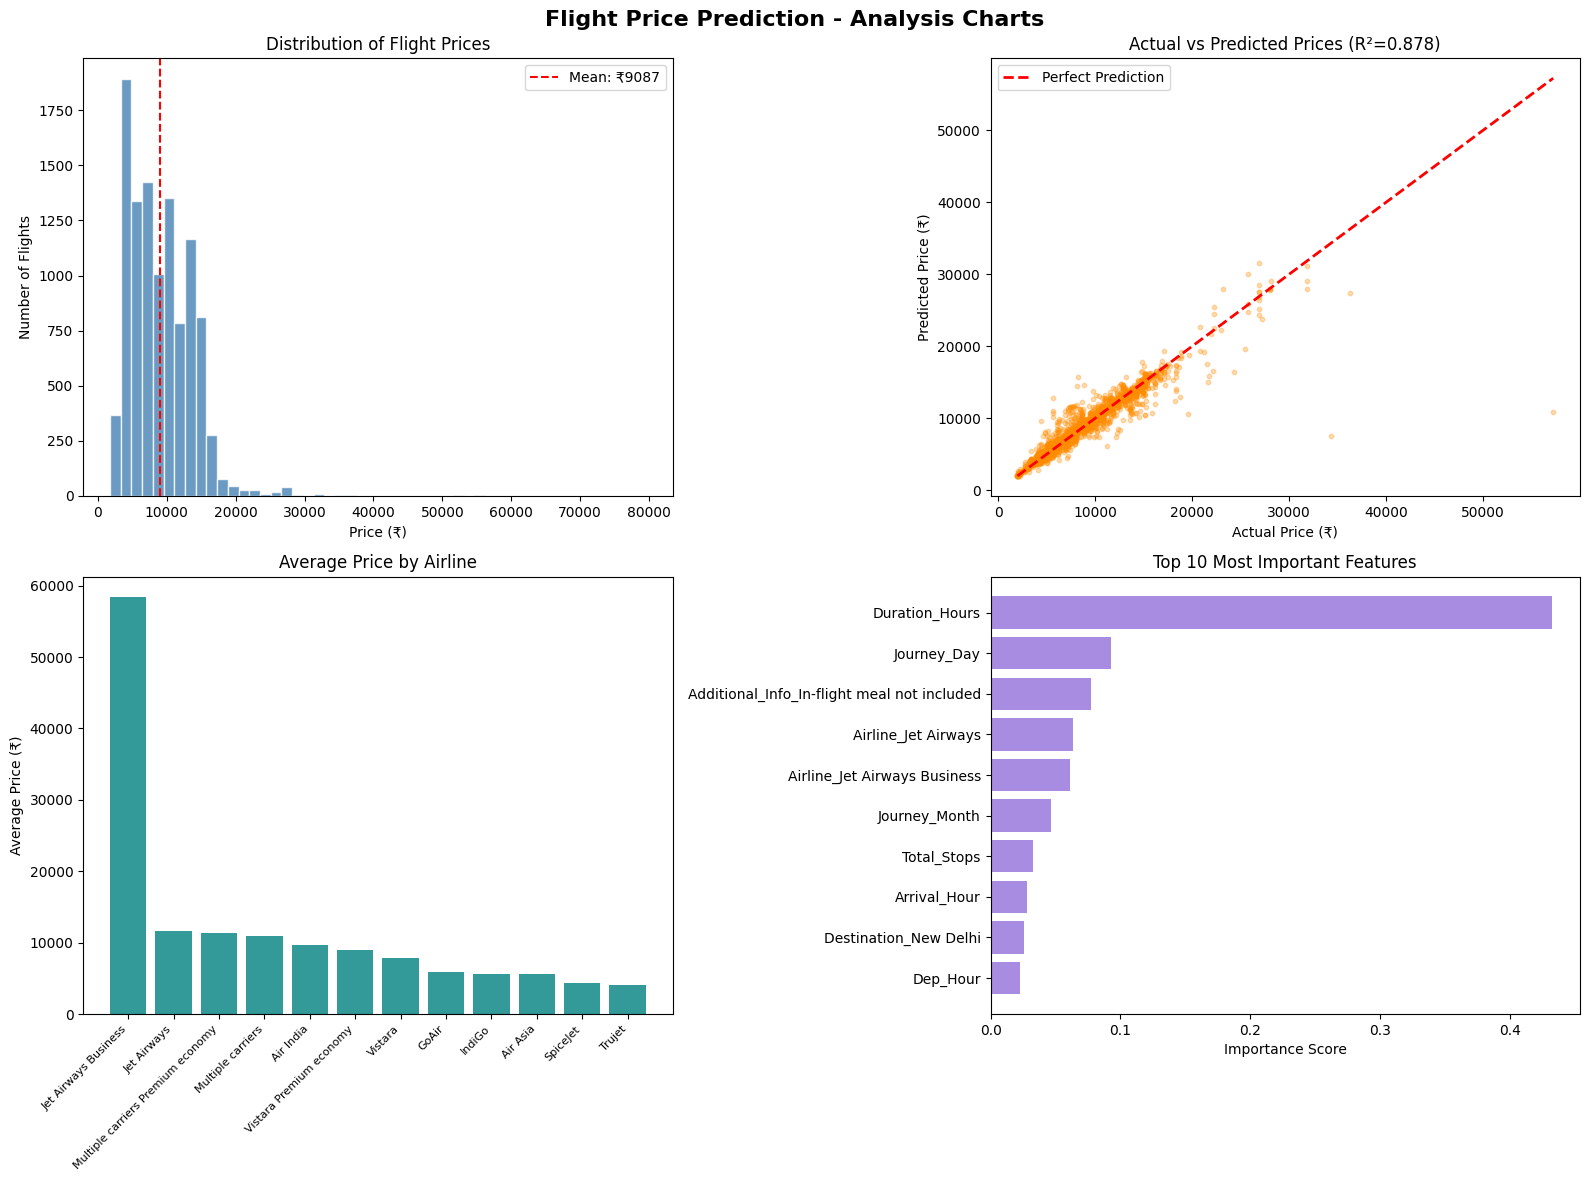

   ✅ Charts saved to: Flight_Price_Analysis.png


In [92]:
# ============================================================
# STEP 14: VISUALIZATIONS (CHARTS)
# ============================================================
# Create charts to better understand the data and model
 
print("\n📉 STEP 14: Creating Visualizations...")
 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Flight Price Prediction - Analysis Charts', fontsize=16, fontweight='bold')
 
# Chart 1: Price Distribution
axes[0,0].hist(y, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('Distribution of Flight Prices')
axes[0,0].set_xlabel('Price (₹)')
axes[0,0].set_ylabel('Number of Flights')
axes[0,0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: ₹{y.mean():.0f}')
axes[0,0].legend()
 
# Chart 2: Actual vs Predicted
axes[0,1].scatter(y_val, y_pred_val, alpha=0.3, color='darkorange', s=10)
axes[0,1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
               'r--', lw=2, label='Perfect Prediction')
axes[0,1].set_title(f'Actual vs Predicted Prices (R²={r2:.3f})')
axes[0,1].set_xlabel('Actual Price (₹)')
axes[0,1].set_ylabel('Predicted Price (₹)')
axes[0,1].legend()
 
# Chart 3: Average Price by Airline
# Use original train data for this chart
orig_train = pd.read_excel("Data_Train.xlsx").dropna()
airline_avg = orig_train.groupby('Airline')['Price'].mean().sort_values(ascending=False)
axes[1,0].bar(range(len(airline_avg)), airline_avg.values, color='teal', alpha=0.8)
axes[1,0].set_xticks(range(len(airline_avg)))
axes[1,0].set_xticklabels(airline_avg.index, rotation=45, ha='right', fontsize=8)
axes[1,0].set_title('Average Price by Airline')
axes[1,0].set_ylabel('Average Price (₹)')
 
# Chart 4: Feature Importance (Top 10)
top10 = importance_df.head(10)
axes[1,1].barh(top10['Feature'][::-1], top10['Importance'][::-1], color='mediumpurple', alpha=0.8)
axes[1,1].set_title('Top 10 Most Important Features')
axes[1,1].set_xlabel('Importance Score')
 
plt.tight_layout()
plt.savefig('Flight_Price_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ Charts saved to: Flight_Price_Analysis.png")
print("=" * 60)

In [93]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n🎉 PROJECT COMPLETE! SUMMARY")
print("=" * 60)
print(f"   📁 Files created:")
print(f"      1. Submission_Predictions.xlsx  ← Your flight price predictions")
print(f"      2. Flight_Price_Analysis.png    ← Analysis charts")
print(f"\n   📊 Model Performance:")
print(f"      Algorithm : Random Forest Regressor (300 trees)")
print(f"      MAE       : ₹{mae:.0f} (average prediction error)")
print(f"      R² Score  : {r2:.4f} ({r2*100:.1f}% accuracy)")
print(f"\n   🔑 Key Findings:")
print(f"      - Most important factor: Total Stops & Duration")
print(f"      - Price range: ₹{y.min():,} to ₹{y.max():,}")
print(f"      - Average flight price: ₹{y.mean():,.0f}")
print("=" * 60)
print("\n✈️  Done! Your flight price predictions are ready.")


🎉 PROJECT COMPLETE! SUMMARY
   📁 Files created:
      1. Submission_Predictions.xlsx  ← Your flight price predictions
      2. Flight_Price_Analysis.png    ← Analysis charts

   📊 Model Performance:
      Algorithm : Random Forest Regressor (300 trees)
      MAE       : ₹668 (average prediction error)
      R² Score  : 0.8781 (87.8% accuracy)

   🔑 Key Findings:
      - Most important factor: Total Stops & Duration
      - Price range: ₹1,759 to ₹79,512
      - Average flight price: ₹9,087

✈️  Done! Your flight price predictions are ready.
